In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
from scipy.stats import norm

In [101]:
df = pd.read_csv("../data/good/leah_indiv_data/leah_cytotoxicity.csv")
cytotox_melted = df.melt(
    id_vars=["global_id", "E:T=(X:1)"],
    value_vars=[
        "K562-GFP-1", "K562-GFP-2", "K562-GFP-3",
        "Raji-GFP-1", "Raji-GFP-2", "Raji-GFP-3",
    ],
    var_name="Target_Replicate",
    value_name="Percent_Cytotoxicity",
)

cytotox_melted["Target"] = cytotox_melted["Target_Replicate"].str.extract(r"^(K562|Raji)")
cytotox_melted["E:T=(X:1)"] = pd.to_numeric(cytotox_melted["E:T=(X:1)"], errors="coerce")
cytotox_melted["Percent_Cytotoxicity"] = pd.to_numeric(cytotox_melted["Percent_Cytotoxicity"], errors="coerce")

colors = {"K562": "#0072B2", "Raji": "#D55E00"}

for uid, df_u in cytotox_melted.groupby("global_id"):
    fig, ax = plt.subplots(figsize=(3, 3))

    for target in ["K562", "Raji"]:
        df_t = df_u[df_u["Target"] == target]
        g = df_t.groupby("E:T=(X:1)")["Percent_Cytotoxicity"]
        x = np.array(sorted(g.groups.keys()), dtype=float)
        mean = g.mean().reindex(x).to_numpy()
        sd = g.std(ddof=1).reindex(x).to_numpy()

        ax.fill_between(x, 0, mean, color=colors[target], alpha=0.15)
        ax.errorbar(
            x, mean, yerr=sd,
            fmt="s-", markersize=4, linewidth=1.6,
            capsize=2, color=colors[target],
            label=f"{target}",
        )

    ax.set_title(str(uid))
    ax.set_xlabel("E:T (X:1)", fontsize=12)
    ax.set_ylabel("% Target Killed", fontsize=12)
    ax.tick_params(axis="both", which="major", labelsize=12)
    ax.set_ylim(0, 100)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.savefig(f"../results/top_ten_plots/cytotoxicity_{uid}.png", bbox_inches="tight", dpi=300)
    plt.close()

# save a single legend
fig_legend, ax_legend = plt.subplots(figsize=(2, 1))
for target in ["K562", "Raji"]:
    ax_legend.plot([], [], color=colors[target], label=f"{target}", marker="s", linestyle="-")
legend = ax_legend.legend(frameon=False, fontsize=12, loc="center")
ax_legend.axis("off")
fig_legend.savefig("../results/top_ten_plots/cytotoxicity_legend.png", bbox_inches="tight", dpi=300)
plt.close()

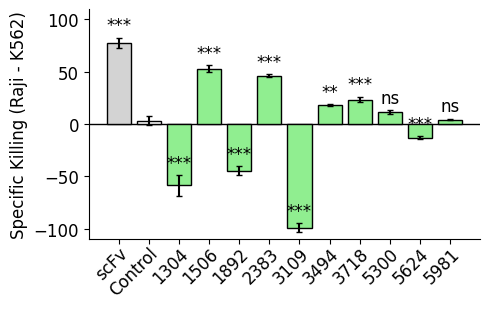

In [103]:
df = pd.read_csv("../data/good/leah_indiv_data/leah_cytotoxicity-agg.csv")
order = df["global_id"].astype(str).tolist()

y = df["diff-avg"].to_numpy()
yerr = df["diff-stderr"].to_numpy()

# colors
colors = np.array(["lightgreen"] * len(df), dtype=object)
colors[order.index("Control")] = "white"
colors[order.index("scFv")] = "lightgrey"

fig, ax = plt.subplots(figsize=(max(5, 0.35 * len(df)), 3.2))
x = np.arange(len(df))

ax.bar(x, y, color=colors, edgecolor="black")
ax.errorbar(x, y, yerr=yerr, fmt="none", ecolor="k", capsize=2, lw=1.5)

ax.set_xticks(x)
# shift a little bit toward center
ax.set_xticklabels(order, rotation=45, ha="right", va="top", fontsize=12, rotation_mode="anchor")
ax.tick_params(axis="x", pad=0)
ax.set_ylabel("Specific Killing (Raji - K562)", fontsize=12)
# y lim -100 to 100
ax.set_ylim(-110, 110)
ax.axhline(0, color="0", linewidth=1, linestyle="-", zorder=0)
# y tick 12
ax.tick_params(axis="y", which="major", labelsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# -----------------------------
# stats: one-sample test vs 0
# -----------------------------
ctrl_idx = order.index("Control")

pvals = []
for i in range(len(y)):
    if i == ctrl_idx:
        pvals.append(1.0)
        continue

    se = np.sqrt(yerr[i]**2 + yerr[ctrl_idx]**2)
    z = (y[i] - y[ctrl_idx]) / se
    p = 2 * (1 - norm.cdf(abs(z)))
    pvals.append(p)

pvals = np.array(pvals)


def bh_adjust(pvals):
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)
    idx = np.argsort(pvals)
    ranks = np.arange(1, m + 1)

    q_sorted = pvals[idx] * m / ranks
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
    q_sorted = np.clip(q_sorted, 0, 1)

    q = np.empty(m, dtype=float)
    q[idx] = q_sorted
    return q

qvals = bh_adjust(pvals)

def stars(q):
    if q < 0.001:
        return "***"
    elif q < 0.01:
        return "**"
    elif q < 0.05:
        return "*"
    else:
        return "ns"

ymax = (y + yerr).max()
offset = 0.04 * ymax

for xi, yi, ei, qi in zip(x, y, yerr, qvals):
    s = stars(qi)

    # if control skip
    if xi == ctrl_idx:
        continue
    ax.text(
        xi,
        yi + ei + offset,
        s,
        ha="center",
        va="bottom",
        fontsize=12,
    )

plt.tight_layout()
plt.savefig("../results/top_ten_plots/specific_killing_topten.png", bbox_inches="tight", dpi=300)

# Bars show mean Raji-specific cytotoxicity AUC (Raji − K562) ± SE; significance stars denote BH-corrected two-sided z-tests comparing each construct to the negative control (ns, not significant; *, p < 0.05; **, p < 0.01; ***, p < 0.001).